# CSCI 6032: Homework 2

## Working Safely with Agents, Git, Docker, and Skills

This homework is about **using AI agents effectively and safely**. It is not about how a language model works internally. You will install GitHub Copilot CLI, give an agent a bounded workspace, use Git checkpoints before delegating changes, construct a reproducible Linux development container, run an agent inside that container, and create a reusable skill that helps submit the completed homework.

The notebook is the spine of your submission. Treat it as a laboratory notebook: record what you tried, what happened, false starts, corrections, and what you learned. The code, tests, `Dockerfile`, agent instructions, and skill must remain as ordinary files in the repository.

**Due: Thursday, September 17, 2026, 11:00 PM.**

## Learning objectives

After completing this homework, you should be able to:

1. Install, authenticate, and run a command-line coding agent.
2. Explain the difference between instructions, permissions, and an operating-system sandbox.
3. Restrict an agent to a designated project directory.
4. Use Git commits as recovery checkpoints before and after agent work.
5. Inspect and test an agent's changes rather than accepting them blindly.
6. Build and run a small Linux development environment with Docker.
7. Bind-mount a host repository into a container without exposing unrelated host files.
8. Run GitHub Copilot CLI inside the container and verify that changes persist on the host.
9. Package a repeated workflow as an agent skill.
10. Use browser automation with explicit human approval at an irreversible step.

## Grading and use of AI

You may use AI in any way you find useful on this homework. You remain responsible for every command you approve, every file you submit, and every claim in this notebook.

This homework is graded primarily on **completeness; reproducible evidence; and thoughtful reflection**. A failed attempt can be valuable evidence when you explain the failure and how you diagnosed it. 

Never present an agent's statement as verification. Verification means that you inspected the relevant state yourself—for example, with `git status`, `git diff`, a test command, a file listing, or a Blackboard confirmation page.

## Safety rules

These rules apply throughout the assignment.

- Never place passwords, API keys, access tokens, private keys, authentication cookies, browser profiles, or Blackboard credentials in the repository, notebook, prompts, Dockerfile, image, skill, or screenshots.
- Redact usernames, email addresses, tokens, device codes, and other private information from captured output.
- Launch the host agent from the homework repository—not from your home directory or a broad parent directory.
- Read each requested command before approving it. Deny a command you do not understand and ask the agent to explain.
- Do not use destructive Git commands, rewrite history, or force-push.
- Do not mount your home directory, `.ssh`, or Docker socket into the container.
- Authenticate interactively. Do not put credentials in the Dockerfile or bake them into an image layer.  You can login using the browser and then let copilot drive from there when you want to automate the web.
- You must personally authenticate to Blackboard.

If you accidentally expose a credential, revoke it. Removing it in a later commit does not remove it from Git history.  You can rewrite git history, but it must be done explicitly.

## What you will submit

You will create a GitHub repository named:

```text
csci6032-hw2-<your-github-username>
```

Clearly anyone can look at this repository.  That is fine.

The repository will contain this completed notebook and the supporting artifacts. At the end, your submission skill will prepare a compressed archive from a clean, committed revision and use your authenticated browser session to help submit:

1. `CSCI6032_hw2.ipynb`
2. `csci6032-hw2-<your-github-username>.tar.gz`
3. The URL of the public GitHub repository.

Do not include the repository's `.git` directory in the archive. The public GitHub repository preserves the Git history.

If publishing your repository would expose information that should not be public, contact the instructor before publishing it.

## Part 0. Access and preparation (5 points)

Use your own GitHub account. If you do not already have Copilot access, request the GitHub Education student benefit immediately. Approval can take time. GitHub Copilot CLI is available with current Copilot plans; consult the instructor if account approval becomes a blocker.

Related links:

- [GitHub Education](https://github.com/education)
- [Install GitHub Copilot CLI](https://docs.github.com/en/copilot/how-tos/copilot-cli/set-up-copilot-cli/install-copilot-cli)
- [Authenticate GitHub Copilot CLI](https://docs.github.com/en/copilot/how-tos/copilot-cli/set-up-copilot-cli/authenticate-copilot-cli)

Record:

- your host operating system and version;
- the date you requested or confirmed Copilot access;
- whether access is active;
- any setup obstacle and how you addressed it.

Do not include personal documents or screenshots from the student-verification process.

### Part 0 laboratory record

**Host operating system and version:**

**Answer**

OS Name: Microsoft Windows 11 Pro
Version: 10.0.22631 Build 22631

**Copilot access status and date:**

**Answer**

Student Application Approved on September 10, 2026

**Setup notes, including any false starts:**

**Answer**

Set up remote on github and pulled it down. Added python virtual environment dependency file and a convienent batch file to setup venv, install/update needed dependencies to run Jupyter Notebook. Copied over the HW 2 notebook. Installed copilot CLI and authenticated with my credentials. I also installed Github cli and the github copilot GUI app just in case. No problems or big blockers so far.

## Part 1. Install and run GitHub Copilot CLI on the host (10 points)

Install the current stable GitHub Copilot CLI using one of the methods in the official documentation. Record the method and version; do not assume that commands copied from an old tutorial remain current.

After installation:

1. Run `copilot version`.
2. Run `copilot login` or start `copilot` and use `/login`.
3. Complete the interactive browser or device-code flow yourself.
4. Start an interactive session and enter this prompt:

```text
Reply with exactly: Hello, CSCI 6032.
```

5. Exit the agent cleanly.

This is the agent equivalent of a Hello World exercise. It verifies access before the assignment introduces files, tools, and permissions.

### Part 1 laboratory record

Record the installation method, the redacted output of `copilot version`, and the Hello World response. Do not paste authentication codes, tokens, or account details.

**Answer**

Used npm in the terminal to install copilot. 

copilot version output:</br>
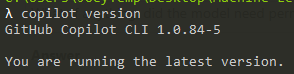

Hello CSCI 6032 response:</br>
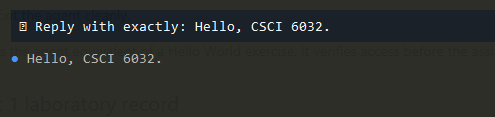

There was no information that needs redacting for the version output or hello world output.

What, if anything, did the model need permission to do for the Hello World prompt? Why?

**Answer**

It did not need any permissions because the request just required a simple text response. I call each distinct action that a language model can take as an "agentic appendage". For example, online search, image creation, and local file editing are three examples of what I'd call and agentic appendage. This request did not require copilot to use any agentic appendage, so there were no need to ask for permissions.

## Part 2. Create the repository and its first checkpoint (10 points)

On GitHub, create the public repository named `csci6032-hw2-<your-github-username>`, initialize it with a `README.md`, and clone it onto your host computer.

Copy this notebook into the repository root as `CSCI6032_hw2.ipynb`. Add a small UTF-8 text file named `sample.txt` containing at least five lines of text that you wrote yourself. Update `README.md` with the course, homework title, repository URL, your host operating system, and a short description.

Before invoking an agent on the repository, inspect the state:

```bash
git remote -v
git status
git diff
```

Commit and push these initial files. Use this commit message:

```text
checkpoint: repository before agent changes
```

Create and switch to a branch named `agent-work` before continuing. Confirm that the working tree is clean.

### Part 2 laboratory record

Paste a concise, redacted record showing:

- the repository URL;
- the initial checkpoint commit identifier;
- the current branch;
- a clean `git status` after the checkpoint.

**Answer**

Repo URL:</br>
https://github.com/j0371/csci6032-hw2-j0371.git

First Agent Checkpoint Commit:</br>
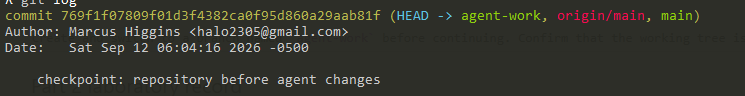

Current Branch With Clean Working Directory:</br>
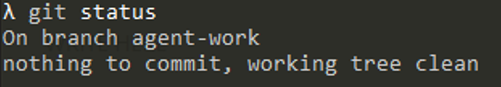

Why is a commit more useful than merely copying a few files before an agent works?

**Answer**

Apart from the general risk of losing local backups if your device loses the data, and the absolute nightmare that it is to try to do version control manually with local file and folder backups, I can think of three good reasons as to why it's more useful to make a commit, along with making sure you push it to the remote.

If you have an agent running locally, then having your backups on that same machine risks having the AI modify or delete the backups along with the original working copies of your work in the case of a policy breach. It doesn't seem completely full proof. For example, if the agent has terminal access, it could potentially run permanently damaging commands like `git reset` or `git rebase` along with a force push to the remote using the same authentication credentials that you use to access the remote in the terminal. However, it still seems like a far better and more reliable backup strategy than putting it on the same machine that you're running the agent on, and for large projects, you could set up proper restrictions on the remote main with required PR approvals to make it much harder for the agent to do something like this.

It makes reviewing the agent's changes easier. Having a clean working directory before the agent starts modifying things allows you to do a simple git diff to `HEAD` in order to check what the agent is doing. If you intermingle a large amount of your changes with the agent's, it's essensially impossible to untangle what code is yours vs. the agent's.

It gives a clean seperation between code that you own, and the code that the agent wrote. I can see this being helpful for things like debugging issues. Having that clean seperation along with branching for each agent checkpoint sort of turns your agent into an independent contributor to the project, making it easier to track down chunks of related functionality especially if you adhere to proper branching techniques of one branch per Product Backlog Item (PBI) or feature implementation.

## Part 3. Constrain the host agent (10 points)

Create `AGENTS.md` at the root of the repository. You may ask an agent to draft it, but you must inspect and revise the result. It must instruct agents to:

1. Work only inside the current repository.
2. Never read, print, store, commit, or upload secrets, credentials, private keys, browser data, or configuration files that may contain them.
3. Explain an intended change before editing.
4. Ask before installing software, accessing a new network destination, deleting files, changing Git history, committing, or pushing.
5. Preserve uncommitted user work and avoid destructive Git commands and force-pushes.
6. Check `git status` before editing and stop if unrelated changes are present.
7. Make small, reviewable changes.
8. Show `git diff` after editing and run the smallest relevant test.
9. Explain errors rather than silently ignoring them.
10. Never claim success without checking the requested result.

Start Copilot CLI from the repository root. Enable local sandboxing when it is available, then inspect its actual state and policy with:

```text
/sandbox enable
/sandbox status
/sandbox policy
```

The current working directory should be writable; unrelated host locations should not be writable. Do not add broad path grants. If local sandboxing is unavailable on your platform or version, document that result and rely on the repository boundary, permission prompts, and the Docker phase that follows.

Commit `AGENTS.md` with the message `docs: add agent safety instructions` and push the branch.

### Part 3 laboratory record

Summarize the effective sandbox policy without exposing personal paths. State whether sandboxing was active and whether you changed any default permissions.

**Answer**

There is some preparation required for me to enable sandboxing. I need to enable the experimental build of copilot CLI and also update windows to the latest version. Because of this, I'm going to make an additional commit after the creation of `AGENTS.md` to include all of the other repo changes to ensure I have a remote backup before restarting for the OS update.</br>

Progress Update 1: I've been messing with the windows update and my Desktop is fighting me (Environment issues are always the worst). This PC has had an issue with windows updates for a long time now but I've never looked into fixing it because it hasn't been much of a problem prior. I Really would prefer to use the sandbox when unleashing LLM automation on my machine for the first time, but if I don't get Windows to cooperate after messing with it a bit longer, I'm just gonna log the failed attempt and move on.</br>

Progress Update 2: I'm gonna try it on my laptop environment. Installing node js -> installing copilot through NPM

=> Sanboxing is working on my laptop!

Running `/sandbox policy`, I can't identify why copilot would need some of these readonly path grants that were set by the default policy. However, most of those paths seem to be for accessing certain executables and utilites from the terminal, and there's nothing concerning that it would have access to in those paths, so I am leaving the default path grants for now.

Explain why `AGENTS.md` is useful but is not, by itself, a security boundary.

**Answer**

It is useful because it better informs the agent of what you want done and how to do it. Specifically regarding undesriable behaviour that can result in destrcutive local modification/deletion and problematic consequences using your credentials on the internet. Due to the sycophantic nature of current language models, they do seem to genuinly try their best at doing things the way that you want them to have done, so it is quite useful to be able to just build out an explicit natural language policy so the agent can get a clear and detailed understanding of the safety procedures that you would like for it to adhere to.

This is not a proper security boundary alone because it is just natural language instruction that you are requesting that the agent understand and adhere to. It is not a solid, rigidly defined restriction that the agent is forced to adhere to under any kind of enforcement outside of the agent's own decernment.

I can identify two potential scenarios that showcase this. The first being the ever-unsolved problem of misalignment, or at the least, something adjacently related to it. True misalignment doesn't seem to be to much of an issue with every day LLM use at the present. However, the type of sycophancy that current LLMs adhere to, seem to me to be very short-sighted which causes it to rigidly cling too closley to a very literal and narrow-sighted idea of what it is that the user wants. It almost always assumes the implicit premises that the user doesn't themselves call into question. it will rarely take on a "take a step back" approach to question whether or not what the user is requesting is actually what they want, or if the way the user is going about handling the problem is even practical. In some cases, the agent will happily go along with a method of problem solving that the user has just assumed is the way they're supposed to go about it. Even in cases when, in reality, that method isn't even possible to accomplish the task. In general, this leads into "paper clip optimzing" behaviour and can easily continue in this loop for as long as the user still thinks that it's feasable. Behaviour like this becomes really concerning in regards to the safety of an agent running autonomously and without needing user approval. If one of these implicit assumptions that the user has not thought to question is a security blindspot, the agent will not think twice before just moving right along with the breach in the spirit, or the semantic meaning of, the stated policy as the user intended it to be interpreted.

The other problem scenario is just when there is a geniune misunderstanding caused by either the way the user expressed the policy, or in the way the agent interpreted it. This is very similar to the first reason in terms of both the cause and the consequence. However, this kind of mistake is a lot more human-like. it's very easy to concieve of a failure in communication in this way between two humans, and it actually is a constant cause of interpersonal problems between people in everyday life.

## Part 4. Generate and review code with the host agent (15 points)

Begin with a clean working tree on `agent-work`. Ask the host agent to complete this bounded task:

```text
Create a small Python command-line program in src/text_stats.py. It must read
one UTF-8 text file and print JSON containing the number of lines, words, and
characters. Add tests using Python's built-in unittest framework, document the
usage in README.md, and test the program with sample.txt. Do not add external
Python dependencies. Do not commit or push. Before editing, explain your plan;
after editing, show the diff and run the tests.
```

You may clarify the prompt or help the agent recover from errors. Do not ask it to work outside the repository.

When it finishes:

1. Run `git status` and `git diff` yourself.
2. Read every changed file.
3. Run the tests yourself.
4. Run the program on `sample.txt` and independently check at least one reported count.
5. Correct any problem, recording whether you or the agent made the correction.
6. Commit the reviewed result as `feat: add agent-generated text statistics tool`.
7. Push `agent-work`.

### Part 4 laboratory record

Record the exact prompt you used if it differs from the supplied prompt. Include selected agent output that shows planning, tool use, and verification; do not paste an enormous transcript.

**Answer**

#### **Pre-Planning:**</br>
I noticed that in the assignments prior instructions, there was no explicit pointing copilot to the `AGENTS.md` file, so I prompted
```
Do not look into the contents of `AGENTS.md` for the moment. I would like to know if you are already aware of what your agency policy is. are you? and if so, give me a small summary
```
<a href="./NotebookAssets/PolicyConfirmed.png" target="_blank" rel="noopener noreferrer">Image of Full Request/Response</a></br></br>
I wasn't aware that [AGENTS.md is a specially recognized filename](https://github.blog/changelog/2025-08-28-copilot-coding-agent-now-supports-agents-md-custom-instructions/) for copilot to automatically adhere to the policy of when it accesses the repository, so I ran this check to ensure it was following the policy and it confirmed that it knew the policy with an accurate summary of it.</br>

I also had an idea for a new policy rule to do a self-audit and record its workflow into a log folder named `Workflows`. I workshopped it by writing a rough draft then workshopping it with ChatGpt then added it as rule 11 in the agents file. Something to note: It seems like copilot automatically reads and adheres to the policy detailed in the agents file when it first spins up in the repo's directory, but if you make changes to the policy while the same instance of copilot is still running, you have to instruct it to review the updated policy in order for it to be aware of the changes.

#### **Making the Request:**</br>

I ran the exact prompt given. The agent ran into a small bug during its workflow, but fixed it without any manual intervention from me so the only input needed from me was accepting permission requests. It created the python script and a test file with three test cases. ran the test and found a bug, edited the script to fix the bug, ran the test again and verified that it's working correctly.

#### **Trimmed Agent Reasoning Output for planning, script creation, testing, verification, and test output:**

Planning:</br>
```
Read csci6032-hw2-j0371, lines 1 to 200

Read README.md, lines 1 to 220

Read sample.txt, lines 1 to 200

Created 1 todo
```
Script Creation:</br>
```
ran mkdir src; mkdir tests

Edited text_stats.py | <--- this is a bit of odd wording because it needed to create the file here, not edit an existing one

Edited test_text_stats.py
```
Testing and Verification:</br>
```
ran python -m unittest discover -s tests -v | <--- Copilot finds bug during test, then edits the script to fix it

Edited test_text_stats.py

Read README.md, lines 1 to 40

Edited README.md

python -m unittest discover -s tests -v; Write-Host "---"; python src/text_stats.py sample.txt
Created 1 todo
```
Test Output:</br>
```
Ran 3 tests in 0.126s

OK
```

Full Workflow log found in <a href="./SavedWorkflowLogs/text-stats-workflow.ipynb" target="_blank" rel="noopener noreferrer">SavedWorkflowLogs/text-stats-workflow.ipynb</a>

Sidenote: This test log notebook was the first one that copilot generated after I implemented the Audit/Logging Policy. Honestly, this is a pretty cool policy and it's awesome that it works. It might be overkill to log every workflow instance, but It's good for an assignment like this, and for other projects, it can be decoupled from the main policy and used as a skill on demand when the user prompts a workflow log for one in the context.

Record the test command and result, the independent check you performed, and the commit identifier.

**Answer**

Running `python .\src\text_stats.py sample.txt`:</br>
```
{"lines": 5, "words": 55, "characters": 281}
```

Running `python -m unittest discover -s tests -v`:</br>
```
test_cli_outputs_json_for_sample_file (test_text_stats.TextStatsTests) ... ok
test_cli_requires_file_argument (test_text_stats.TextStatsTests) ... ok
test_count_text_stats_function (test_text_stats.TextStatsTests) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.134s

OK
```

Commit Identifier: `3df0fcbcff706fa8c151e13e74ffc69ca200e9f3` > feat: add agent-generated text statistics tool

What did you inspect before deciding that the change was safe to commit? Did the agent do anything unexpected?

**Answer**

I inspected all of the folder and file changes through VSC's diff checker and making sure I understood the python code that it generated. I'm not familiar with python's unittest, and I don't have all too much experience with automated test cases, but I looked over the code, and familiarized myself with what the test case inputs were as well as what the assertions were evaluating. I ran the test cases manually and ran the script itself manually to verify that it outputs correctly for `sample.txt`. The workflow went smoothly without any problems or unexpected behaviour. It is interesting to see the agent process an entire
```
|build out feature -> build tests -> test feature -> Identify bug -> debug and fix found bug -> retest -> verify output|
```
process within one automated workflow mostly indepedendently. It is cool that it can do all of this instead of stopping at the "found a bug during testing" phase then just stop processing the workflow and flag the bug to the user by basically saying "I made the script and the tests but there's this one bug in it that's causing the test to fail" then wait for the user to either fix it themselves or to have to manually instruct the agent to debug and fix to make the script work.

## Part 5. Install and verify Docker on the host (10 points)

Install Docker Desktop or Docker Engine using the current official instructions for your operating system:

- [Docker Desktop overview and platform installers](https://docs.docker.com/desktop/)
- [Docker Engine installation](https://docs.docker.com/engine/install/)

Start Docker and verify it from a host terminal:

```bash
docker version
docker run --rm hello-world
```

The first command should show both client and server information. The second should retrieve and run a small test image successfully.

If institutional or hardware restrictions prevent a normal installation, contact the instructor early rather than weakening the assignment's safety requirements.

### Part 5 laboratory record

Record the Docker product, installation method, version, and a concise excerpt showing that `hello-world` ran. Note any virtualization, WSL, permission, or architecture issue you encountered.

**Answer**

I installed Docker Desktop from the link in the assignment. I needed to install the linux subsystem for windows, so I ran `wsl --install` and verified the wsl installation and that the path variable was set by running the executable in the terminal. The version of Docker that was installed is 29.8.0 for both the client and server.

The header message of the terminal output when running `docker run --rm hello-world`:
```
Hello from Docker!
This message shows that your installation appears to be working correctly.
```

## Part 6. Create a minimal Linux agent development image (15 points)

Use an agent to help create a `Dockerfile`, but inspect and understand every instruction. The image must provide:

- a small, current Linux base suitable for Python development;
- Python 3.12 or later and `pip`;
- Git;
- GitHub CLI (`gh`);
- the current stable GitHub Copilot CLI;
- certificates and only the additional utilities needed for installation;
- a non-root development user;
- `/workspace` as the working directory.

The image must **not** contain your repository, tokens, credentials, browser profile, Docker socket, or a copy of a host credential directory. Do not use a floating prerelease of Copilot CLI. Prefer a reproducible version argument or record the resolved Copilot version.

Build the image with the tag:

```text
csci6032-hw2-agent
```

Start an interactive container with only the homework repository bind-mounted read/write at `/workspace`. Docker recommends the explicit `--mount` syntax. Have your agent adapt the following pattern to your shell and operating system:

```text
docker run --rm -it --mount type=bind,src=<ABSOLUTE-PATH-TO-REPOSITORY>,dst=/workspace csci6032-hw2-agent
```

Do not mount a broad parent directory. On native Linux, you may need to account for the host user's UID and GID so the non-root container user can write to the mounted repository; document any adjustment.

Inside the container, verify:

```bash
id
pwd
python --version
git --version
gh --version
copilot version
git status
```

Authenticate `gh` and Copilot interactively from inside the container using their browser/device flows. Do not paste a token into a Docker command, Dockerfile, notebook, or shell history. Demonstrate GitHub access with a read-only command such as `gh repo view`; redact account details in the notebook.

### Part 6 laboratory record

Paste your complete `Dockerfile` here as a fenced code block. Explain the purpose of each major layer and how the non-root user is created.

**Answer**

I wanted to see how well the agent would do with a more complex automated task so I asked it to look at part six and set up everything that this part requires. It didn't make any mistakes, but I ran into an auth issue. Since I can't access the terminal it's using, I cannot auth the gh cli in the agent's session. So, I took over to manually set up the rest after that point. The full redacted workflow can be found at <a href="./SavedWorkflowLogs/part6-agent-image-workflow.ipynb" target="_blank" rel="noopener noreferrer">SavedWorkflowLogs/part6-agent-image-workflow.ipynb</a> which includes its own partially worked version of part 6 of the assignment.

Dockerfile code (The comments in the script are copilot's. I marked each layer that I explain myself below the script):</br>
```dockerfile

#Layer 1---------------------------------------------------------------------
# Use a minimal, current Python 3.12 base image suitable for development
FROM python:3.12-slim-bookworm

# Update package lists and install essential build and runtime dependencies
# ca-certificates: for TLS trust when downloading packages
# curl, wget: for downloading tools (e.g., Copilot CLI)
# git: version control system
# gnupg: needed for verifying GitHub CLI package signatures
RUN apt-get update && apt-get install -y --no-install-recommends \
    ca-certificates \
    curl \
    wget \
    git \
    gnupg \
    && rm -rf /var/lib/apt/lists/*

#Layer 2---------------------------------------------------------------------
# Install GitHub CLI (gh) from the official repository
# This layer adds the GitHub CLI key and repository, then installs gh
RUN curl -fsSL https://cli.github.com/packages/githubcli-archive-keyring.gpg | gpg --dearmor -o /usr/share/keyrings/githubcli-archive-keyring.gpg && \
    printf 'deb [arch=%s signed-by=/usr/share/keyrings/githubcli-archive-keyring.gpg] https://cli.github.com/packages stable main\n' "$(dpkg --print-architecture)" > /etc/apt/sources.list.d/github-cli.list && \
    apt-get update && apt-get install -y --no-install-recommends gh && \
    rm -rf /var/lib/apt/lists/*

# Install the current stable GitHub Copilot CLI (standalone) from an explicit release asset
# Use a pinned release from the official copilot-cli repo for reproducibility
RUN curl -fsSL https://github.com/github/copilot-cli/releases/download/v1.0.88/copilot-linux-x64.tar.gz -o /tmp/copilot.tar.gz && \
    tar -xzf /tmp/copilot.tar.gz -C /tmp && \
    install -m 0755 /tmp/copilot /usr/local/bin/copilot && \
    rm -f /tmp/copilot /tmp/copilot.tar.gz

#Layer 3---------------------------------------------------------------------
# Create a non-root user 'agent' with fixed UID/GID for consistency
# This allows the user to read/write bind-mounted repositories on the host
RUN groupadd -g 1000 agent && \
    useradd -u 1000 -g 1000 -m -s /bin/bash agent

#Layer 4---------------------------------------------------------------------
# Create and own the /workspace directory
RUN mkdir -p /workspace && \
    chown -R agent:agent /workspace

# Set /workspace as the working directory
WORKDIR /workspace

# Default to a shell so interactive container use behaves like a development terminal
CMD ["/bin/bash"]

# Switch to the non-root user for all subsequent operations
USER agent

```

Layer 1:</br>
This sets up the debian-based python environment then uses curl to install and update necessary dependencies.

Layer 2:</br>
Installs the Github and copilot CLI into the container.

Layer 3:</br>
sets up the user group that the agent will use in the container.

Layer 4:</br>
creates the workspace and sets the container to use that workspace. it also starts up a bash terminal to use. Finally, it sets the user to `agent` that was created in layer three.

\----</br>
The dockerfile sets up the non-root user by creating a user group with GID 1000 then uses that GID to create a user with UID 1000 and named agent in that group. Then the last line of the file sets the container to use the agent user.

Record the exact build and run commands with private path components replaced by a placeholder. Include concise, redacted verification output from inside the container.

**Answer**

Terminal Command that the agent used to build the image (pulled from audit log):</br>
`docker build -t csci6032-hw2-agent .`

Terminal Command I used to spin up the docker container:</br>
`docker run --rm -it --mount "type=bind,src=\<REDACTED_FILE_PATH\>,dst=/workspace" csci6032-hw2-agent`

Running verification commands inside the container:</br>
```
agent@48e30d38c1ce:/workspace$ id
uid=1000(agent) gid=1000(agent) groups=1000(agent)

agent@48e30d38c1ce:/workspace$ pwd
/workspace

agent@48e30d38c1ce:/workspace$ python --version
Python 3.12.14

agent@48e30d38c1ce:/workspace$ gh --version
gh version 2.101.0 (2026-09-15)
https://github.com/cli/cli/releases/tag/v2.101.0

agent@48e30d38c1ce:/workspace$ copilot version
copilot version 1.2.0 (2025-10-30)

agent@48e30d38c1ce:/workspace$ git status
On branch agent-work
Your branch is up to date with 'origin/agent-work'.
nothing to commit, working tree clean
```

What host resources can the container modify through the bind mount? What important resources did you deliberately not mount?

**Answer**

The only host resources that the container, and therefore the contained agent, can modify is the root directory of this assignment's repo and all the subfolders within it. I considered not including the `Workflows` diretory which won't show up in the remote repo (git ignored) for the same reason. The agent policy says to not use any sensitive info, but the audit log notebooks have a ton of text in them that I can't vet to ensure that there isn't any senstive info. So, I have the workflow logs not included in the repo, and if there's a log I want to include, I vet just that specific one then place it in the `SavedWorkflowLogs` folder. For this reason, I was considering not mounting the workflows folder, but I'm deciding against it because if an agent on the host made the log, then I don't see an issue with a containerized agent having access to it considering that the host agent only ever accessed the same content inside the repo that the container has mounted.

## Part 7. Run an agent inside the container (10 points)

Before the container agent edits anything, return to the host, inspect the repository, and commit the reviewed `Dockerfile` and current notebook with the message:

```text
checkpoint: add container before container agent changes
```

Confirm that the tree is clean. Start the container again with the repository mounted at `/workspace`, launch Copilot CLI from `/workspace`, confirm the sandbox and repository boundary, and give it this task:

```text
Extend src/text_stats.py with an optional --top N argument that reports the N
most frequent words, case-insensitively, with deterministic tie-breaking.
Update the unittest tests and README.md. Do not add external dependencies. Do
not commit or push. First inspect the existing project and explain your plan.
After editing, show the diff and run all tests.
```

After the agent finishes:

1. Exit the container.
2. Confirm on the host that the bind-mounted changes persisted.
3. Inspect the entire diff and run the tests on the host.
4. Try the new option with `sample.txt` and check the result.
5. Commit the reviewed change as `feat: add top-words option from container agent`.
6. Push the branch.

### Part 7 laboratory record

Provide selected evidence that Copilot ran inside the container, changed the bind-mounted repository, and ran tests. Include the checkpoint and post-agent commit identifiers.

**Answer**

During this workflow, I caught copilot breaking explicit instructions in the `AGENTS.md` policy file! My policy states to review all other policy files in `/Policies/` because I have a workflow audit policy, but it didn't even look in the `/Policies/` folder at all. I had the agent format my interogation of it in <a href="./SavedWorkflowLogs/policy-break-discussion.ipynb" target="_blank" rel="noopener noreferrer">SavedWorkflowLogs/policy-break-discussion.ipynb</a> with the main points of its responses in bold.

Here's the trimmed down workflow self-audit of the agent's work:
```
----
I first added a Counter, word-matching, and argparse-based CLI parsing

Command run > python -m unittest discover -s tests -v
Observed result:

FAIL: test_cli_requires_file_argument
FAIL: test_count_top_words_function_is_case_insensitive_and_deterministic
Ran 5 tests in 1.051s
FAILED (failures=2)

----
I replaced the generic argparse handling with a small explicit parser.

Command run > python -m unittest discover -s tests -v

Observed result:
Ran 5 tests in 0.869s
OK

----
Modified files:
    src/text_stats.py: added case-insensitive top-word counting and optional CLI parsing.
    tests/test_text_stats.py: added helper and CLI coverage for the new option.
    README.md: documented --top N and its JSON output.
```

I looked over all the file changes myself in VSC on my host to make sure the changes persisted then ran the test cases and a manual `Sample.txt` run:

\>`python .\src\text_stats.py sample.txt --top 2`
```
{"lines": 5, "words": 55, "characters": 281, "top_words": [["i", 4], ["the", 3]]}
```
\>`python -m unittest discover tests/`
```
Ran 5 tests in 0.227s
OK
```

Checkpoint before agent workflow:</br>
`1022406bc342f1c835d99b4e01f330cf047c76aa` > checkpoint: add container before container agent changes

Checkpoint after agent workflow:</br>
`c3ffd03f09f5ab93cc4c197ad07d44ee63156bb8` > feat: add top-words option from container agent

Describe at least one difference between running the agent directly on the host and running it in the container. Which boundary protected the host, and which host files were intentionally exposed?

**Answer**

When I started up copilot in the container the first thing I did was ask it what it had access to, to make sure I had the bind-mounting and non-root user set up properly.

I requested this to the contained agent:</br>
`explore this container and tell me what you have access to`
And was somewhat suprised that it so plainly started looking at content outside of the repo (but still within the container)
```
> I can see the standard Linux filesystem, including /, /usr, /tmp, /home, etc.
> I’m not restricted to just the repo; I can inspect the container’s runtime environment.
```
This is kind of a grey-area policy break of my AGENTS.md file in my opinion, but this made me go ask copilot on my host, and its summary does not state any kind of **"not restricted to just the repo"** statements like the containerized one.
I requested this to the agent on my host:</br>
`explore your environment and tell me what you have access to`</br>
and it responded saying it knew the absolute path to the repo, but everything else was stuff like this:
```
> Cannot access files outside these paths
> Cannot access your home directory outside the repo
```

I wonder if me mentioning that it was a container in the request made it more bold about what it could do.

\----</br>
Installing copilot and running it within the container is what protected my host machine from the agent's changes. I intentionally exposed the root directory of the repo so that the agent could make changes to any files and subfolders within it. I did this when I ran the `docker run` with the bind-mounting argument `"type=bind,src=<REDACTED_FILE_PATH>,dst=/workspace"` and setting the absolute file path of the repo as the source path.

## Part 8. Add browser tools on the host (5 points)

Return to the **host** Copilot installation for this part. Do not attempt to share your Chrome profile with the development container.

GitHub Copilot CLI includes Playwright browser tools. To allow an agent to operate a tab in your existing authenticated Chrome session, install the instructor-approved [Playwright MCP Bridge extension](https://github.com/microsoft/playwright/tree/main/packages/extension) and configure a project-level Playwright MCP server in extension mode by following the current [Playwright MCP documentation](https://github.com/microsoft/playwright-mcp) and [GitHub Copilot MCP documentation](https://docs.github.com/en/copilot/how-tos/copilot-cli/customize-copilot/add-mcp-servers).

Important boundaries:

- Install only the extension linked by the instructor.
- Review the permissions Chrome requests.
- Connect only the Blackboard tab needed for this assignment.
- Keep the default connection approval; do not store an extension connection token in the repository.
- Project MCP configuration is executable configuration. Read it before trusting the folder.
- Test the browser connection with a read-only action, such as asking the agent to report the title of the selected tab.

Do not allow the agent to submit anything during this test.

### Part 8 laboratory record

Record the extension name and source, the location of the MCP configuration, and the result of the read-only browser test. Do not paste cookies, tokens, Blackboard contents, grades, or personal information.

**Answer**

Extension name is "Playwright Extension" on the chrome web store at:</br>
`https://chromewebstore.google.com/detail/playwright-extension/mmlmfjhmonkocbjadbfplnigmagldckm`

The MCP configuration that I have for the repo is located at `./.mcp.json` relative to the repo root.

Copilot's read-only test result:</br>
```
Confirmed — I have access to the Playwright MCP bridge and it's connected to your Blackboard tab:


**Tab title:** "Content / Fall Semester 2026-2027 Machine Learning (CSCI-6032-001, CSCI-4999A-004)"

**URL:** `https://blackboard.olemiss.edu/ultra/courses/_164662_1/outline`


This was a read-only listing only — I have not clicked, typed, or submitted anything. Let me know if you'd like me to do anything further
```

What additional authority did connecting the browser give the agent?

**Answer**

By connecting to the Playwright MCP Bridge through the mcp server I configured, this gives the agent the ability to view and agentically interact with the selected tab. Since the selected tab is a session of my signed-in blackboard page, this gives the agent the authority to interact with blackboard with my account.

## Part 9. Create a Blackboard submission skill (5 points)

Create a project skill at:

```text
.github/skills/blackboard-submission/SKILL.md
```

You may use Copilot to draft the skill. The `SKILL.md` file must have valid YAML frontmatter containing a lowercase hyphenated `name` and a precise `description`. Do not include `allowed-tools: "*"`, and do not preapprove shell or browser tools. The point is to preserve visible permission boundaries.

The skill must implement this workflow:

1. Confirm that it is operating in the expected homework repository.
2. Run a preflight that checks the current branch, `git status`, recent commits, expected remote URL, and required files.
3. Stop if the tree is not clean, required artifacts are absent, or unresolved secrets/private data are apparent.
4. Confirm that the reviewed branch has been pushed.
5. Prepare `csci6032-hw2-<your-github-username>.tar.gz` from the committed `HEAD` without including `.git`, credentials, caches, or unrelated files.
6. List the archive contents and show the exact notebook, archive, repository URL, and submission text it proposes to use.
7. Support a **dry run** that performs every possible check without opening Blackboard or submitting.
8. Ask before opening or controlling the Blackboard tab.
9. Require the student to authenticate personally; never request, read, store, type, or expose credentials.
10. Navigate only to this homework's submission page and stage the required files and repository URL.
11. Stop immediately before the final, irreversible submission action and show the student exactly what will be submitted.
12. Require explicit confirmation at that point. A prior general approval is not sufficient.
13. After confirmation, complete the submission, verify the confirmation page or receipt, and report the result.
14. Do not commit Blackboard screenshots, receipts, browser data, or personal information to the public repository.

Review the current [GitHub agent skills documentation](https://docs.github.com/en/copilot/how-tos/copilot-cli/customize-copilot/add-skills). Reload and inspect the skill with `/skills reload`, `/skills list`, and `/skills info blackboard-submission`.

Commit the skill and final notebook changes as:

```text
feat: add Blackboard submission skill
```

Push the branch. Then return to your repository's default branch, merge
`agent-work` **without squashing**, and push the default branch. Resolve and
review any conflict rather than asking Git to discard one side. Run the tests
again after the merge. The default branch, working tree, and remote must agree
before you create the submission archive.

### Part 9 laboratory record

Paste your complete `SKILL.md` here as a fenced code block.

**Answer**

WRITE HERE

Describe one material change you made after reviewing the agent's draft of the skill.

**Answer**

WRITE HERE

Why must the skill ask again immediately before the final submission action?

**Answer**

WRITE HERE

## Part 10. Dry-run and use the submission skill

Invoke `/blackboard-submission` in dry-run mode first. Resolve every reported problem. Inspect the archive contents yourself, confirm the repository is public and up to date, and confirm that no secret or private information is included.

Then invoke the skill for the real submission. Personally authenticate to Blackboard. Let the skill prepare the submission, inspect the staged files and text, and provide explicit confirmation only when they are correct. Verify the resulting Blackboard confirmation.

Do not modify the committed notebook afterward merely to record that submission succeeded; doing so would make the submitted archive differ from the repository checkpoint. Instead, enter this short statement in Blackboard alongside the repository URL:

```text
I used my blackboard-submission skill, reviewed the staged artifacts, explicitly
approved the final submission action, and verified Blackboard's confirmation.
```

If the automation cannot safely complete the final click, perform that click yourself, verify the result, and explain the limitation in the Blackboard comment. Safe human completion is preferable to bypassing a security boundary.

## Required Git history and repository contents

Your public repository must show, at minimum, these ordered checkpoints:

1. `checkpoint: repository before agent changes`
2. `docs: add agent safety instructions`
3. `feat: add agent-generated text statistics tool`
4. `checkpoint: add container before container agent changes`
5. `feat: add top-words option from container agent`
6. `feat: add Blackboard submission skill`

Equivalent additional commits are welcome. Do not squash these checkpoints.

Required contents:

```text
CSCI6032_hw2.ipynb
README.md
AGENTS.md
sample.txt
Dockerfile
src/
  text_stats.py
tests/
  test_text_stats.py
.github/
  skills/
    blackboard-submission/
      SKILL.md
```

Your project-level MCP configuration may be committed only if it contains no secret, personal path, browser data, or extension token. Otherwise, document its structure in the notebook and exclude it from the repository.

## Final reflection (5 points)

Answer each question in a short paragraph.

1. Where did Git provide protection, and where did it not?
2. How did the host sandbox and Docker container differ as boundaries?
3. Which agent output required the most human judgment?
4. What did the agent do that saved you time?
5. What would you change before allowing an agent to work on a valuable research repository?

**Answer**

WRITE HERE

## Grading summary

| Component | Points |
|---|---:|
| Access and preparation | 5 |
| Host Copilot installation and Hello World | 10 |
| Repository and initial checkpoint | 10 |
| Agent instructions and host boundary | 10 |
| Host-agent code generation and review | 15 |
| Docker installation | 10 |
| Linux agent development image | 15 |
| Agent work inside the container | 10 |
| Browser tools | 5 |
| Submission skill | 5 |
| Final reflection | 5 |
| **Total** | **100** |

The real Blackboard submission is required for the homework to be received. If browser automation fails after a documented good-faith attempt, submit manually and document the limitation in the Blackboard comment.

## Documentation references

These links were checked when the assignment was prepared. Tools change quickly; use the current official page when its interface differs from this notebook.

- [Installing GitHub Copilot CLI](https://docs.github.com/en/copilot/how-tos/copilot-cli/set-up-copilot-cli/install-copilot-cli)
- [Authenticating GitHub Copilot CLI](https://docs.github.com/en/copilot/how-tos/copilot-cli/set-up-copilot-cli/authenticate-copilot-cli)
- [Using local sandboxing](https://docs.github.com/en/copilot/how-tos/cloud-and-local-sandboxes/using-local-sandboxing)
- [Allowing and denying Copilot CLI tools](https://docs.github.com/en/copilot/how-tos/copilot-cli/use-copilot-cli/allowing-tools)
- [Adding agent skills](https://docs.github.com/en/copilot/how-tos/copilot-cli/customize-copilot/add-skills)
- [Adding MCP servers](https://docs.github.com/en/copilot/how-tos/copilot-cli/customize-copilot/add-mcp-servers)
- [Docker Desktop](https://docs.docker.com/desktop/)
- [Docker Engine installation](https://docs.docker.com/engine/install/)
- [Docker bind mounts](https://docs.docker.com/engine/storage/bind-mounts/)
- [Playwright MCP](https://github.com/microsoft/playwright-mcp)
- [Playwright MCP Bridge extension](https://github.com/microsoft/playwright/tree/main/packages/extension)